## Title & Objective

# Week 5 – Deep Learning Model Development  
## Predictive Maintenance for IT Infrastructure

Objectives:
- Build LSTM model for temporal learning
- Build GRU model for sequence prediction
- Implement Autoencoder for anomaly detection
- Analyze training performance using graphs

## Import Libraries

In [20]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM,
    GRU,
    Dense,
    Dropout,
    Input,
    RepeatVector,
    TimeDistributed
)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

## Load Sequence Dataset

In [21]:
X_seq = np.load("X_seq.npy")
y_seq = np.load("y_seq.npy")

print("X shape:", X_seq.shape)
print("y shape:", y_seq.shape)

X shape: (9982, 10, 11)
y shape: (9982,)


## Train-Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    random_state=42
)

print("Training sequences:", X_train.shape)
print("Testing sequences:", X_test.shape)

Training sequences: (7985, 10, 11)
Testing sequences: (1997, 10, 11)


In [23]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.5597224169353708), 1: np.float64(4.686032863849765)}


## Early Stopping
Stops training when validation loss stops improving.

In [24]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

## Build LSTM Model

In [25]:
lstm_model = Sequential()

lstm_model.add(
    LSTM(
        64,
        activation='tanh',
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(32, activation='relu'))

lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 64)             │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,569 (84.25 KB)

 Trainable params: 21,569 (84.25 KB)

 Non-trainable params: 0 (0.00 B)

## Train LSTM Model

In [26]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5457 - loss: 0.6931 - val_accuracy: 0.4746 - val_loss: 0.6979
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5878 - loss: 0.6889 - val_accuracy: 0.4515 - val_loss: 0.7028
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4914 - loss: 0.6858 - val_accuracy: 0.6080 - val_loss: 0.6600
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5435 - loss: 0.6862 - val_accuracy: 0.5160 - val_loss: 0.6879
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5244 - loss: 0.6816 - val_accuracy: 0.5560 - val_loss: 0.6784
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5620 - loss: 0.6783 - val_accuracy: 0.4784 - val_loss: 0.6901
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5621 - loss: 0.6729 - val_accuracy: 0.4928 - val_loss: 0.6958
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5540 - loss: 0.6664 - val_accuracy: 0

## Plot LSTM Accuracy

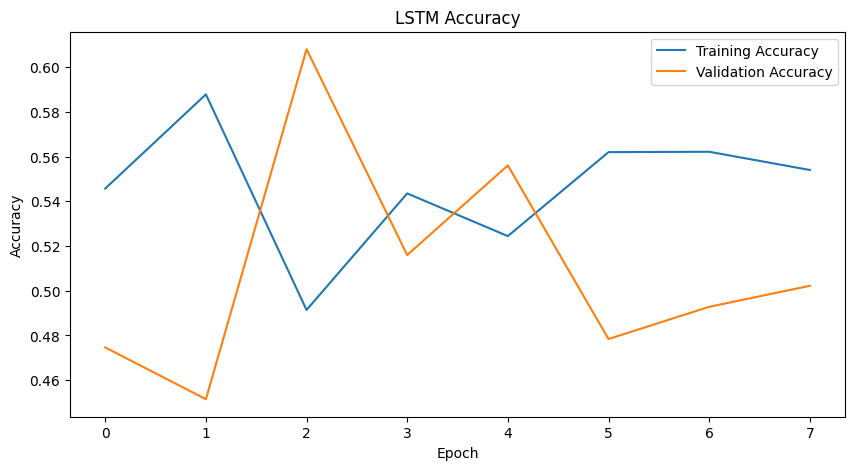

In [27]:
plt.figure(figsize=(10,5))

plt.plot(history_lstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')

plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## Plot LSTM Loss

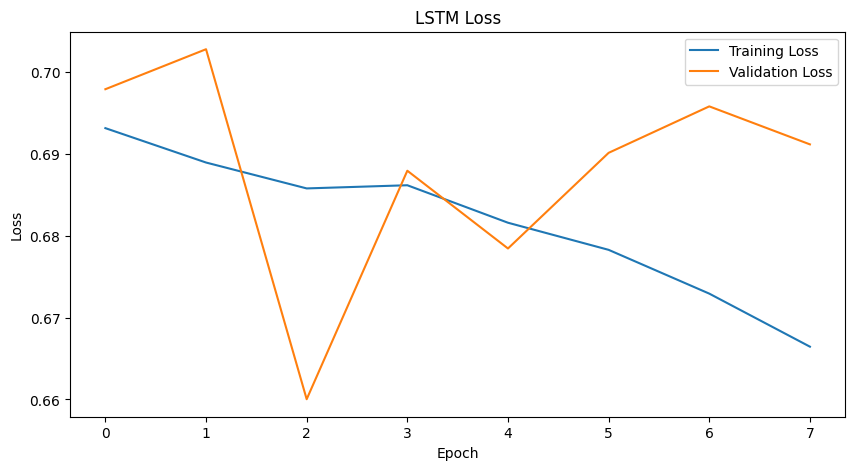

In [28]:
plt.figure(figsize=(10,5))

plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')

plt.title("LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Evaluate LSTM

In [29]:
lstm_loss, lstm_acc = lstm_model.evaluate(X_test, y_test)

print("LSTM Accuracy:", lstm_acc)
print("LSTM Loss:", lstm_loss)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6214 - loss: 0.6602
LSTM Accuracy: 0.6214321255683899
LSTM Loss: 0.6602378487586975


## LSTM Predictions

In [30]:
y_pred_lstm = (lstm_model.predict(X_test) > 0.3).astype(int)

print(classification_report(y_test, y_pred_lstm))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
              precision    recall  f1-score   support

           0       1.00      0.00      0.00      1785
           1       0.11      1.00      0.19       212

    accuracy                           0.11      1997
   macro avg       0.55      0.50      0.10      1997
weighted avg       0.91      0.11      0.02      1997



## Build GRU Model

In [31]:
gru_model = Sequential()

gru_model.add(
    GRU(
        64,
        activation='tanh',
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

gru_model.add(Dropout(0.2))

gru_model.add(Dense(32, activation='relu'))

gru_model.add(Dense(1, activation='sigmoid'))

gru_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

gru_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 64)             │        14,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,897 (66.00 KB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 0 (0.00 B)

## Train GRU Model

In [33]:
history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weights
)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.5958 - loss: 0.6930 - val_accuracy: 0.3100 - val_loss: 0.7181
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5061 - loss: 0.6891 - val_accuracy: 0.4721 - val_loss: 0.6956
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5056 - loss: 0.6862 - val_accuracy: 0.5679 - val_loss: 0.6753
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5266 - loss: 0.6855 - val_accuracy: 0.5053 - val_loss: 0.6878
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5589 - loss: 0.6821 - val_accuracy: 0.4828 - val_loss: 0.6984


## Evaluate GRU

In [34]:
gru_loss, gru_acc = gru_model.evaluate(X_test, y_test)

print("GRU Accuracy:", gru_acc)
print("GRU Loss:", gru_loss)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3010 - loss: 0.7168
GRU Accuracy: 0.30095142126083374
GRU Loss: 0.7167776823043823


## Prepare Normal Data Only

In [35]:
normal_indices = np.where(y_train == 0)[0]

X_train_normal = X_train[normal_indices]

print("Normal training data:", X_train_normal.shape)

Normal training data: (7133, 10, 11)


## Build Autoencoder

In [36]:
timesteps = X_train.shape[1]
features = X_train.shape[2]

inputs = Input(shape=(timesteps, features))

# Encoder
encoded = LSTM(64, activation='tanh')(inputs)

# Bottleneck
bottleneck = RepeatVector(timesteps)(encoded)

# Decoder
decoded = LSTM(64, activation='tanh', return_sequences=True)(bottleneck)

outputs = TimeDistributed(Dense(features))(decoded)

autoencoder = Model(inputs, outputs)

autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

autoencoder.summary()

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 10, 11)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 10, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 10, 11)         │           715 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,195 (207.79 KB)

 Trainable params: 53,195 (207.79 KB)

 Non-trainable params: 0 (0.00 B)

## Train Autoencoder

In [37]:
history_ae = autoencoder.fit(
    X_train_normal,
    X_train_normal,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.6680 - val_loss: 0.6157
Epoch 2/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.5900 - val_loss: 0.5625
Epoch 3/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.5534 - val_loss: 0.5280
Epoch 4/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.5186 - val_loss: 0.4943
Epoch 5/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.4886 - val_loss: 0.4733
Epoch 6/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.4675 - val_loss: 0.4512
Epoch 7/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.4484 - val_loss: 0.4353
Epoch 8/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.4305 - val_loss: 0.4151
Epoch 9/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.4152 - val_loss: 0.4003
Epoch 10/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.4032 - val_loss: 0.3909
Epoch 11/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.3902 - val_loss: 0.3812
Epoch 12/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 

## Reconstruction Error

In [38]:
reconstructions = autoencoder.predict(X_test)

mse = np.mean(np.power(X_test - reconstructions, 2), axis=(1,2))

threshold = np.percentile(mse, 95)

print("Anomaly Threshold:", threshold)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Anomaly Threshold: 0.441330823924841


## Detect Anomalies

In [39]:
anomaly_predictions = (mse > threshold).astype(int)

print(classification_report(y_test, anomaly_predictions))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92      1785
           1       0.11      0.05      0.07       212

    accuracy                           0.85      1997
   macro avg       0.50      0.50      0.50      1997
weighted avg       0.81      0.85      0.83      1997



## Plot Reconstruction Errors

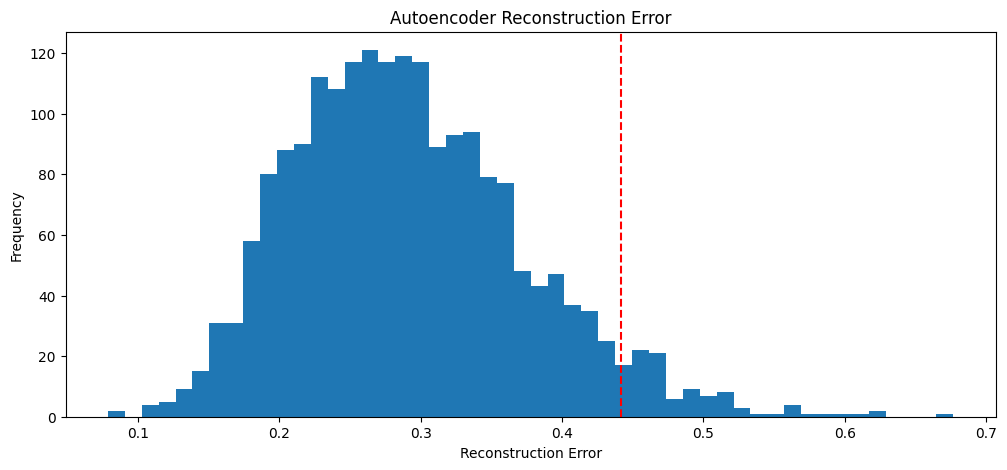

In [40]:
plt.figure(figsize=(12,5))

plt.hist(mse, bins=50)

plt.axvline(threshold, color='red', linestyle='--')

plt.title("Autoencoder Reconstruction Error")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")

plt.show()

## Save Models

In [ ]:
lstm_model.save("lstm_model.h5")
gru_model.save("gru_model.h5")
autoencoder.save("autoencoder_model.h5")